In [198]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import lambertw

## Anytime valid CIs

In [ ]:
T = 500
reps = 20
alpha = 0.05
widths = np.zeros((7, T))
Ts = np.arange(1, T+1)

for rep in range(reps):

    X = np.random.beta(1, 1, size=T)
    
    # CLT interval
    mean = np.cumsum(X) / Ts
    clt_width = 1.96 * np.asarray([np.std(X[:t]) for t in Ts]) / np.sqrt(Ts)
    clt_width[0] = 1.96 * (1 / 2)
    widths[0] += 2 * clt_width
        
    # Hoeffding (incorrect)
    mean = np.cumsum(X) / Ts
    lam = np.sqrt(8 * np.log(1 / alpha) / Ts)
    width = np.log(2 / alpha) / (Ts * lam)  + lam / 8
    hl_lb = np.maximum.accumulate(mean - width)
    hl_ub = np.minimum.accumulate(mean + width)
    widths[1] += hl_ub - hl_lb
        
    # Hoeffding (fixed lambda)
    mean = np.cumsum(X) / Ts
    lam = np.sqrt(8 * np.log(1 / alpha) / T)
    width = np.log(2 / alpha) / (Ts * lam)  + lam / 8
    hl_lb = np.maximum.accumulate(mean - width)
    hl_ub = np.minimum.accumulate(mean + width)
    widths[2] += hl_ub - hl_lb
    
    # Hoeffding (Gaussian mixture)
    mean = np.cumsum(X) / Ts
    rho = T / (-lambertw(-alpha**2 / np.e, k=-1).real - 1)
    # rho2 = 4 / T
    # c = 1 + rho2 * Ts / 4
    # width = np.sqrt( 2 * c / rho2 * (np.log(2 / alpha) + np.log(c) / 2) ) / Ts
    width = np.sqrt( (Ts + rho) * np.log( (Ts + rho) / alpha**2 / rho )) / Ts
    hl_lb = np.maximum.accumulate(mean - width)
    hl_ub = np.minimum.accumulate(mean + width)
    widths[3] += hl_ub - hl_lb
        
    # Hoeffding (plug in)
    lambdas = np.minimum(np.sqrt(8 * np.log(2/alpha) / Ts / np.log(Ts+1)), 1)
    mean = np.cumsum(lambdas * X) / np.cumsum(lambdas)
    width = (np.log(2 / alpha) + np.cumsum(lambdas**2 / 8)) / np.cumsum(lambdas)
    h_lb = np.maximum.accumulate(mean - width)
    h_ub = np.minimum.accumulate(mean + width)
    widths[4] += h_ub - h_lb
        
    # Bernstein (plug in)
    mu_hats = (1/2 + np.cumsum(X)) / (Ts + 1)
    sigma_hats = (1/4 + np.cumsum((X - mu_hats) ** 2 ) ) / (Ts + 1)
    lambdas = np.sqrt(2 * np.log(2 / alpha) / Ts / np.log(Ts + 1) / np.concatenate([[1/4], sigma_hats[:-1]]))
    lambdas = np.minimum(lambdas, 1/2)
    nus = 4 * (X - np.concatenate([[1/2], mu_hats[:-1]])) ** 2
    psi = ( - np.log(1 - lambdas) - lambdas) / 4
    mean = np.cumsum(lambdas * X) / np.cumsum(lambdas)
    b_lb = mean - ( np.log(2 / alpha) + np.cumsum(nus * psi) ) / np.cumsum(lambdas)
    b_ub = mean + ( np.log(2 / alpha) + np.cumsum(nus * psi) ) / np.cumsum(lambdas)
    b_lb = np.maximum.accumulate(b_lb)
    b_ub = np.minimum.accumulate(b_ub)
    widths[5] += b_ub - b_lb
         
    # Betting-based
    theta = 0.5
    mu_hats = (1/2 + np.cumsum(X)) / (Ts + 1)
    sigma_hats = (1/4 + np.cumsum((X - mu_hats) ** 2 ) ) / (Ts + 1)
    lambdas = np.sqrt(2 * np.log(2 / alpha) / Ts / np.log(Ts + 1) / np.concatenate([[1/4], sigma_hats[:-1]]))
    grid = np.linspace(0, 1, 1000)
    bb_lb = np.zeros(T)
    bb_ub = np.zeros(T)

    for i in range(1, T+1):
        Kp = np.asarray([
            theta * np.prod(1 + np.minimum(lambdas[:i], 1 / m / 2) * (X[:i] - m)) +
            (1 - theta) * np.prod(1 - np.minimum(lambdas[:i], 1 / (1-m) / 2) * (X[:i] - m))
            for m in grid])
        idx = np.where(Kp < (1 / alpha))[0]
        bb_lb[i-1] = grid[idx[0]]
        bb_ub[i-1] = grid[idx[-1]]
    bb_lb = np.maximum.accumulate(bb_lb)
    bb_ub = np.minimum.accumulate(bb_ub)
    widths[6] += bb_ub - bb_lb

widths /= reps

/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_23857/2595226921.py:76: RuntimeWarning: divide by zero encountered in scalar divide
  theta * np.prod(1 + np.minimum(lambdas[:i], 1 / m / 2) * (X[:i] - m)) +
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_23857/2595226921.py:77: RuntimeWarning: divide by zero encountered in scalar divide
  (1 - theta) * np.prod(1 - np.minimum(lambdas[:i], 1 / (1-m) / 2) * (X[:i] - m))


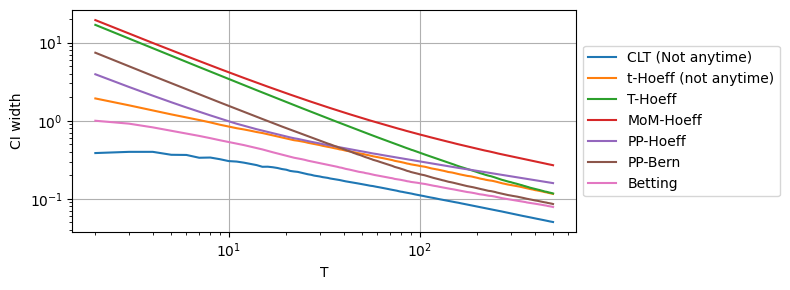

In [228]:
names = ['CLT (Not anytime)', 't-Hoeff (not anytime)', 'T-Hoeff', 'MoM-Hoeff', 'PP-Hoeff', "PP-Bern", "Betting"]

plt.figure(figsize=(8, 3))
xrange = np.arange(1, T+1)

# for name, width in zip(names, widths):
#     axes[0].plot(xrange, width * xrange, label=name)

for name, width in zip(names, widths):
    plt.plot(xrange[1:], width[1:], label=name)
    
plt.grid(True)
plt.xlabel('T')
plt.ylabel('CI width')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

## Monitoring

In [231]:
T = 200
reps = 100
alpha = 0.05
n_methods = 4
Ts = np.arange(1, T+1)
ps = [0.5, 0.6, 0.7, 0.8, 0.9]
null = 0.5

coverage = np.zeros((4, len(ps)))
bias = np.zeros((4, len(ps)))
t_stop = np.zeros((4, len(ps)))
widths = np.zeros((4, len(ps)))

for rep in range(reps):
    
    for j, p in enumerate(ps):

        X = np.random.binomial(1, p=p, size=T)

        # Hoeffding (fixed lambda)
        mean = np.cumsum(X) / Ts
        lam = np.sqrt(8 * np.log(1 / alpha) / T)
        width = np.log(2 / alpha) / (Ts * lam)  + lam / 8
        hl_lb = np.maximum.accumulate(mean - width)
        hl_ub = np.minimum.accumulate(mean + width)

        if np.any(hl_lb > null):
            idx = np.where(hl_lb > null)[0][0]
        else:
            idx = T-1
        
        t_stop[0, j] += idx+1
        coverage[0, j] += (hl_lb[idx] < p) & (hl_ub[idx] > p)
        bias[0, j] += mean[idx] - p
        widths[0, j] += hl_ub[idx] - hl_lb[idx]
        
        # Hoeffding (plug in)
        lambdas = np.minimum(np.sqrt(8 * np.log(2/alpha) / Ts / np.log(Ts+1)), 1)
        mean = np.cumsum(lambdas * X) / np.cumsum(lambdas)
        width = (np.log(2 / alpha) + np.cumsum(lambdas**2 / 8)) / np.cumsum(lambdas)
        h_lb = np.maximum.accumulate(mean - width)
        h_ub = np.minimum.accumulate(mean + width)
        
        if np.any(h_lb > null):
            idx = np.where(h_lb > null)[0][0]
        else:
            idx = T-1
        
        t_stop[1, j] += idx+1
        coverage[1, j] += (h_lb[idx] < p) & (h_ub[idx] > p)
        bias[1, j] += mean[idx] - p
        widths[1, j] += h_ub[idx] - h_lb[idx]
            
        # Bernstein (plug in)
        mu_hats = (1/2 + np.cumsum(X)) / (Ts + 1)
        sigma_hats = (1/4 + np.cumsum((X - mu_hats) ** 2 ) ) / (Ts + 1)
        lambdas = np.sqrt(2 * np.log(2 / alpha) / Ts / np.log(Ts + 1) / np.concatenate([[1/4], sigma_hats[:-1]]))
        lambdas = np.minimum(lambdas, 1/2)
        nus = 4 * (X - np.concatenate([[1/2], mu_hats[:-1]])) ** 2
        psi = ( - np.log(1 - lambdas) - lambdas) / 4
        mean = np.cumsum(lambdas * X) / np.cumsum(lambdas)
        b_lb = mean - ( np.log(2 / alpha) + np.cumsum(nus * psi) ) / np.cumsum(lambdas)
        b_ub = mean + ( np.log(2 / alpha) + np.cumsum(nus * psi) ) / np.cumsum(lambdas)
        b_lb = np.maximum.accumulate(b_lb)
        b_ub = np.minimum.accumulate(b_ub)
        
        if np.any(b_lb > null):
            idx = np.where(b_lb > null)[0][0]
        else:
            idx = T-1
        
        t_stop[2, j] += idx+1
        coverage[2, j] += (b_lb[idx] < p) & (b_ub[idx] > p)
        bias[2, j] += mean[idx] - p
        widths[2, j] += b_ub[idx] - b_lb[idx]
            
        # Betting-based
        theta = 0.5
        mu_hats = (1/2 + np.cumsum(X)) / (Ts + 1)
        sigma_hats = (1/4 + np.cumsum((X - mu_hats) ** 2 ) ) / (Ts + 1)
        lambdas = np.sqrt(2 * np.log(2 / alpha) / Ts / np.log(Ts + 1) / np.concatenate([[1/4], sigma_hats[:-1]]))
        grid = np.linspace(0, 1, 1000)
        bb_lb = np.zeros(T)
        bb_ub = np.zeros(T)

        for i in range(1, T+1):
            Kp = np.asarray([
                theta * np.prod(1 + np.minimum(lambdas[:i], 1 / m / 2) * (X[:i] - m)) +
                (1 - theta) * np.prod(1 - np.minimum(lambdas[:i], 1 / (1-m) / 2) * (X[:i] - m))
                for m in grid])
            idx = np.where(Kp < (1 / alpha))[0]
            bb_lb[i-1] = grid[idx[0]]
            bb_ub[i-1] = grid[idx[-1]]
        bb_lb = np.maximum.accumulate(bb_lb)
        bb_ub = np.minimum.accumulate(bb_ub)
        
        if np.any(bb_lb > null):
            idx = np.where(bb_lb > null)[0][0]
        else:
            idx = T-1
        
        t_stop[3, j] += idx+1
        coverage[3, j] += (bb_lb[idx] < p) & (bb_ub[idx] > p)
        i = idx+1
        Kp = np.asarray([
                theta * np.prod(1 + np.minimum(lambdas[:i], 1 / m / 2) * (X[:i] - m)) +
                (1 - theta) * np.prod(1 - np.minimum(lambdas[:i], 1 / (1-m) / 2) * (X[:i] - m))
                for m in grid])
        point_est = grid[np.argmin(Kp)]
        bias[3, j] += point_est - p
        widths[3, j] += bb_ub[idx] - bb_lb[idx]

bias /= reps
t_stop /= reps
coverage /= reps
widths /= reps

/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_23857/2372296249.py:88: RuntimeWarning: divide by zero encountered in scalar divide
  theta * np.prod(1 + np.minimum(lambdas[:i], 1 / m / 2) * (X[:i] - m)) +
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_23857/2372296249.py:89: RuntimeWarning: divide by zero encountered in scalar divide
  (1 - theta) * np.prod(1 - np.minimum(lambdas[:i], 1 / (1-m) / 2) * (X[:i] - m))
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_23857/2372296249.py:106: RuntimeWarning: divide by zero encountered in scalar divide
  theta * np.prod(1 + np.minimum(lambdas[:i], 1 / m / 2) * (X[:i] - m)) +
/var/folders/sd/v_dt5vp17z75wd22155dfr880000gn/T/ipykernel_23857/2372296249.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  (1 - theta) * np.prod(1 - np.minimum(lambdas[:i], 1 / (1-m) / 2) * (X[:i] - m))


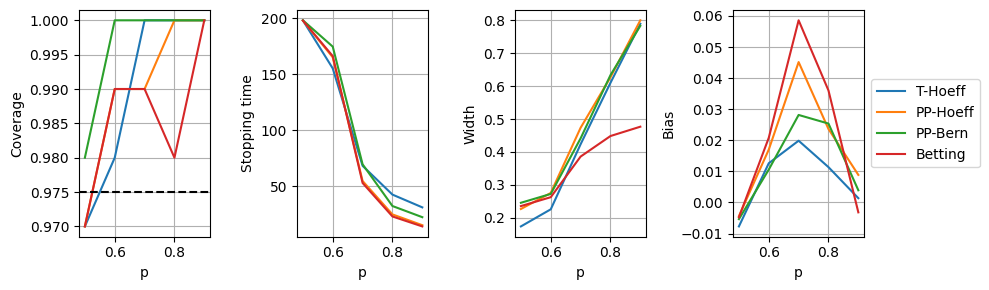

In [232]:
names = ['T-Hoeff', 'PP-Hoeff', "PP-Bern", "Betting"]

_, axes = plt.subplots(1, 4, figsize=(10, 3), sharex=True, sharey=False)

for j, name in enumerate(names):
    axes[0].plot(ps, coverage[j], label=name)
    axes[1].plot(ps, t_stop[j], label=name)
    axes[2].plot(ps, widths[j], label=name)
    axes[3].plot(ps, bias[j], label=name)
    
for ax in axes:
    ax.set_xlabel('p')
    ax.grid(True)

axes[0].set_ylabel('Coverage')
axes[1].set_ylabel('Stopping time')
axes[2].set_ylabel('Width')
axes[3].set_ylabel('Bias')

axes[0].axhline(1-alpha/2, ls='--', c='black')

axes[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

## Bandit sampling

In [ ]:
def exp3(outcomes, eta=1, gamma=0.1):
    n, T = outcomes.shape
    # returns = np.zeros(n)
    p = np.ones(n) / n
    weights = np.ones(n)
    indices = [[] for _ in range(n)]

    for t in range(T):
        qt = (1 - gamma) * p + gamma / n
        noise = np.random.gumbel(0, 1, size=n)
        # gumbel trick, plus mix in uniform noise
        arm = np.argmax(np.log(qt) + noise)
        # returns[arm] += outcomes[t, arm]
        indices[arm].append(t)
        weights[arm] *= np.exp(-eta * outcomes[t, arm] / qt[arm])
        p = weights / np.sum(weights)

    return indices

In [ ]:
bin_size = 10
T = 10
reps = 100
alpha = 0.05
n_methods = 4
Ts = np.arange(1, T+1)
ps = [0.5, 0.6, 0.7, 0.8, 0.9]
null = 0.5

coverage = np.zeros((4, len(ps)))

for rep in range(reps):
    
    for j, p in enumerate(ps):

        X_full = np.asarray([
            np.random.binomial(bin_size, p=null, size=T) / bin_size,
            np.random.binomial(bin_size, p=p, size=T) / bin_size
        ]).T
        sampling = exp3(X_full)

        # Betting-based
        theta = 0.5
        mu_hats = (1/2 + np.cumsum(X)) / (Ts + 1)
        sigma_hats = (1/4 + np.cumsum((X - mu_hats) ** 2 ) ) / (Ts + 1)
        lambdas = np.sqrt(2 * np.log(2 / alpha) / Ts / np.log(Ts + 1) / np.concatenate([[1/4], sigma_hats[:-1]]))
        grid = np.linspace(0, 1, 100)
        bb_lb = np.zeros(T)
        bb_ub = np.zeros(T)

        for i in range(1, T+1):
            Kp = np.asarray([
                theta * np.prod(1 + np.minimum(lambdas[:i], 1 / m / 2) * (X[:i] - m)) +
                (1 - theta) * np.prod(1 - np.minimum(lambdas[:i], 1 / (1-m) / 2) * (X[:i] - m))
                for m in grid])
            idx = np.where(Kp < (1 / alpha))[0]
            bb_lb[i-1] = grid[idx[0]]
            bb_ub[i-1] = grid[idx[-1]]
        for i in range(T-1):
            if bb_lb[i+1] < bb_lb[i]:
                bb_lb[i+1] = bb_lb[i]
            if bb_ub[i+1] > bb_ub[i]:
                bb_ub[i+1] = bb_ub[i]
        
        if np.any(bb_lb > null):
            idx = np.where(bb_lb > null)[0][0]
        else:
            idx = T-1
        
        t_stop[3, j] += idx+1
        coverage[3, j] += (bb_lb[idx] < p) & (bb_ub[idx] > p)
        i = idx+1
        Kp = np.asarray([
                theta * np.prod(1 + np.minimum(lambdas[:i], 1 / m / 2) * (X[:i] - m)) +
                (1 - theta) * np.prod(1 - np.minimum(lambdas[:i], 1 / (1-m) / 2) * (X[:i] - m))
                for m in grid])
        point_est = grid[np.argmin(Kp)]
        bias[3, j] += point_est - p
        widths[3, j] += bb_ub[idx] - bb_lb[idx]

bias /= reps
coverage /= reps